In [1]:
import pandas as pd
df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [5]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [6]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [7]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [8]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [9]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [10]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

In [11]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [12]:
dff = dff.sample(frac=1, random_state=42)

In [13]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

In [14]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [15]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [16]:
from deep_learning_models import UNetThenNN

In [17]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [18]:
# model = ResNetMini()   
# model = ResNetHoliSmokes()
# model = BayesianResNetMini()
# model = UNet()
model = UNetBayesian()
# model = UNetThenNN()

In [19]:
UNetBayesian

deep_learning_models.UNetBayesian

In [20]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,621,902
Trainable parameters: 4,621,902


In [21]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau


patience = 25
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)

best_val_loss = float('inf')
best_weights = None

In [23]:
def gaussian_nll(y_true, mu, log_var):
    """
    Gaussian negative log-likelihood loss.
    Predicts both mean and aleatoric uncertainty (log variance).
    """
    return 0.5 * (log_var + (y_true - mu)**2 / (log_var.exp() + 1e-8)).mean()

In [24]:
# import time 
# import copy
# import torch

# N_MC = 1000  # number of MC samples for epistemic uncertainty at val time
# model.to(device)
# start = time.time()

# for epoch in range(100):
#     # ---- TRAIN ----
#     # single forward pass per batch, dropout active via training=True hardcoded in forward()
#     model.train()
#     epoch_loss = 0.0
#     for xb, yb in train_loader:
#         xb = xb.to(device)
#         yb, paths = yb[0].to(device), yb[1]
#         optimizer.zero_grad()
#         mu, log_var = model(xb)                    # aleatoric: mu + log_var predicted by network
#         loss = gaussian_nll(yb, mu, log_var)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#     train_losses.append(epoch_loss / len(train_loader))

#    # ---- VALIDATION ----
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb = xb.to(device)
#             yb, paths = yb[0].to(device), yb[1]
#             mu, log_var = model(xb)
#             loss = gaussian_nll(yb, mu, log_var)
#             val_loss += loss.item()
#     val_losses.append(val_loss / len(val_loader))
#     scheduler.step()

#     # ---- EARLY STOPPING ----
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         best_weights = copy.deepcopy(model.state_dict())
#         early_stop_counter = 0
#     else:
#         early_stop_counter += 1
#     print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
#     if early_stop_counter >= patience:
#         print(f"Early stopping triggered at epoch {epoch+1}")
#         break
# process_time = time.time() - start

In [25]:
# import os
# import torch

# os.chdir("/home/mbatt/gravitational_lensing/")

# checkpoint = {
#     "model_state_dict": best_weights,   # your best Bayesian model weights
#     "optimizer_state_dict": optimizer.state_dict(),
#     "epoch": epoch,
#     "train_losses": train_losses,
#     "val_losses": val_losses,
#     "process_time": process_time
# }

# torch.save(checkpoint, "resnet_bayesian_2.pth")

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load("resnet_bayesian_2.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


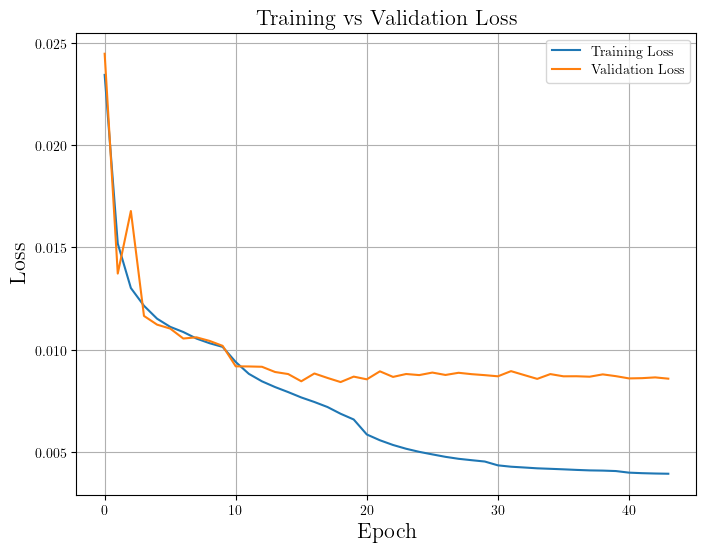

In [27]:
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.title("Training vs Validation Loss", fontsize = 16)
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_8_resnet_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
import time
model.eval()
preds_mu = []
preds_std = []
targets = []
epistemic = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        print(f"batch {i}")
        i += 1
        
        xb = xb.to(device)
        # xb = xb[:,:-1,:,:]
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        start = time.time()
        ouuts = np.stack(
            [model(xb)[0].cpu() for _ in range(100)],
            axis=2)
        print(time.time() - start)
        preds_mu.append(model(xb)[0].cpu())
        preds_std.append(model(xb)[1].cpu())
        epistemic.append(ouuts.std(axis = 2))
        targets.append(yb.cpu())

# concatenate all batches
preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
preds_std = np.concatenate(preds_std, axis = 0)
epistemic = np.concatenate(epistemic, axis = 0)
targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

batch 0
13.390355348587036
batch 1
9.636895418167114
batch 2
9.638540506362915
batch 3
9.636587142944336
batch 4
9.64034128189087
batch 5
9.647237539291382
batch 6
9.653908729553223
batch 7
9.645897626876831
batch 8
9.646779298782349
batch 9
9.651068925857544
batch 10
9.65821886062622
batch 11
9.669487237930298
batch 12
9.668371200561523
batch 13
9.67112684249878
batch 14
9.671871185302734
batch 15
9.674890995025635
batch 16
9.67663049697876
batch 17
9.683370590209961
batch 18
9.686541557312012
batch 19
9.687577247619629
batch 20
9.690008401870728
batch 21
9.692047834396362
batch 22
9.693803310394287
batch 23
9.696025848388672
batch 24
9.696833372116089
batch 25
9.70423698425293
batch 26
9.708423614501953
batch 27
9.709344863891602
batch 28
9.71106481552124
batch 29
9.711127042770386
batch 30
9.71134352684021
batch 31
9.7130868434906
batch 32
9.718142986297607
batch 33
9.719597339630127
batch 34
9.723592281341553
batch 35
9.722372770309448
batch 36
9.731422424316406
batch 37
9.72690415

In [29]:
# --- Compute R2 per parameter ---
y_true_np = targets
y_pred_np = preds_mu
preds_std_np = preds_std
epistemic_np =epistemic

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)

Per-parameter R2: [0.9176351875066757, 0.27024656534194946, 0.26005101203918457, 0.6999943554401398, 0.7245499491691589]


In [30]:
cols = ["r_Einstein_t", "gamma1", "gamma2", "ex", "ey"]

df_uncertainties = pd.concat(
    [
        pd.DataFrame(targets, columns=[f"{c}_true" for c in cols]),
        pd.DataFrame(preds_mu, columns=[f"{c}_pred" for c in cols]),
        pd.DataFrame(preds_std, columns=[f"{c}_aleatoric" for c in cols]),
        pd.DataFrame(epistemic, columns=[f"{c}_epistemic" for c in cols]),
    ],
    axis=1,
)

In [31]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

df_uncertainties.to_csv('uncertainties_bayes.csv')

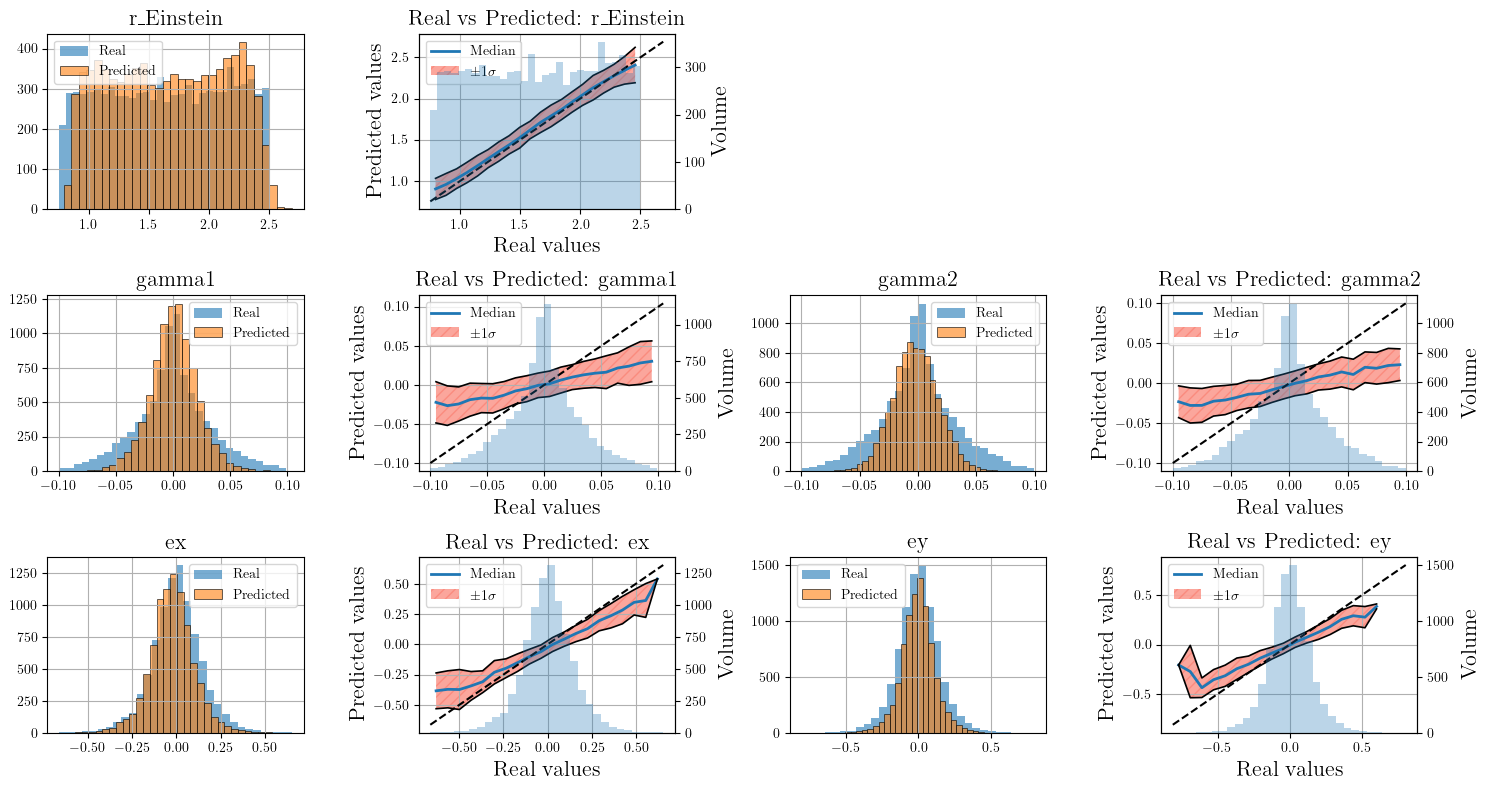

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = y_true_np
y_pred = y_pred_np

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}", fontsize = 16)
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values", fontsize = 16)
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$\pm 1 \sigma$"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume", fontsize = 16)
    
    ax1.set_xlabel("Real values", fontsize = 16)
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}", fontsize = 16)
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_8_resnet_1to1.png", dpi=300, bbox_inches="tight")
plt.show()
